# P3 · Risk Parity: Balancing Risk Instead of Money

*Portfolio & Risk track*

A portfolio that looks balanced in dollars can be very unbalanced in risk. Risk parity gives every asset an equal share of the *risk*, and it needs no forecasts of returns at all.

## 1. Motivation

The classic "balanced" portfolio puts 60% in stocks and 40% in bonds. It sounds diversified. But stocks are several times more volatile than medium-term bonds, so when the portfolio has a bad month, the stock part is almost always the reason. In risk terms, a 60/40 portfolio is close to a 90/10 portfolio. If the goal is diversification, shouldn't we balance the thing that actually hurts?

## 2. Intuition

Think of a tug-of-war team with one heavyweight and four children. Even though there are five people, the result depends almost entirely on the heavyweight. To make the team "balanced", you would want each member to pull equally hard, not just stand on the rope in equal numbers.

In a portfolio, each asset "pulls" on total risk by an amount that depends on two things: **how much of it you hold**, and **how volatile and how correlated with the rest it is**. Risk parity chooses weights so that every asset contributes the same amount of risk. In practice that means less money in volatile assets (stocks) and more in calm ones (bonds).

Because it uses only the covariance matrix and never the expected returns, it avoids the weakest input from P1.

## 3. The math

Portfolio volatility is $\sigma_p = \sqrt{w^\top\Sigma w}$. How much does asset $i$ add? Look at the sensitivity of $\sigma_p$ to $w_i$:
$$
\frac{\partial \sigma_p}{\partial w_i} = \frac{(\Sigma w)_i}{\sigma_p}.
$$
The **risk contribution** of asset $i$ is its weight times that sensitivity:
$$
RC_i = w_i \,\frac{(\Sigma w)_i}{\sigma_p}.
$$
These contributions add up exactly to total risk:
$$
\sum_i RC_i = \frac{w^\top \Sigma w}{\sigma_p} = \sigma_p .
$$
So $RC_i/\sigma_p$ is the *share* of portfolio risk coming from asset $i$.

**Two versions of risk parity:**

1. **Inverse volatility** (the simple version): $w_i \propto 1/\sigma_i$. If all correlations were equal, this would give exactly equal risk contributions.
2. **Equal risk contribution (ERC)** (the full version): find long-only weights with $RC_i = \sigma_p/N$ for every $i$. There is no closed-form solution in general, so we solve it numerically by minimising
$$
\sum_i \left(RC_i - \frac{\sigma_p}{N}\right)^2 \quad \text{subject to } w_i \ge 0,\; \textstyle\sum_i w_i = 1 .
$$

## 4. Code it

### 4.1 Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

prices = pd.read_csv("../data/prices.csv", index_col="date", parse_dates=True)

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})
pd.set_option("display.width", 120)

assets = ["SPY", "VNQ", "IEF", "TLT", "GLD"]   # stocks, real estate, 7-10y and 20y+ Treasuries, gold
returns = prices[assets].pct_change().dropna()
Sigma = returns.cov().values * 252

### 4.2 Risk contributions of a 60/40 portfolio

In [2]:
def risk_contributions(w, Sigma):
    sigma_p = np.sqrt(w @ Sigma @ w)
    return w * (Sigma @ w) / sigma_p            # RC_i = w_i (Sigma w)_i / sigma_p

w_6040 = np.array([0.6, 0.0, 0.4, 0.0, 0.0])   # 60% SPY, 40% IEF
rc = risk_contributions(w_6040, Sigma)
print(f"Portfolio volatility: {np.sqrt(w_6040 @ Sigma @ w_6040):.1%}  (sum of RC_i = {rc.sum():.1%})")
for a, s in zip(assets, rc / rc.sum()):
    print(f"  {a}: {round(s, 3) + 0:6.1%} of total risk")

Portfolio volatility: 9.9%  (sum of RC_i = 9.9%)
  SPY:  99.7% of total risk
  VNQ:   0.0% of total risk
  IEF:   0.3% of total risk
  TLT:   0.0% of total risk
  GLD:   0.0% of total risk


A 60/40 portfolio has 40% of its *money* in bonds, but almost 100% of its *risk* comes from stocks. Two things cause this. Stocks are about three times as volatile as IEF. And over this period IEF was slightly negatively correlated with stocks, so its contribution to risk is close to zero. For a risk manager, 60/40 is a stock portfolio with a cushion.

### 4.3 Inverse volatility and ERC weights

In [3]:
def inverse_vol_weights(Sigma):
    inv = 1 / np.sqrt(np.diag(Sigma))           # w_i proportional to 1 / sigma_i
    return inv / inv.sum()

def erc_weights(Sigma):
    n = len(Sigma)
    def objective(w):
        rc = risk_contributions(w, Sigma)
        return ((rc - rc.sum() / n) ** 2).sum() * 1e4   # squared gaps from sigma_p / N (scaled up for the solver)
    res = minimize(objective, x0=inverse_vol_weights(Sigma), method="SLSQP",
                   bounds=[(0, 1)] * n,                                 # long only
                   constraints={"type": "eq", "fun": lambda w: w.sum() - 1})
    return res.x

portfolios = {
    "60/40": w_6040,
    "Equal weight": np.full(len(assets), 1 / len(assets)),
    "Inverse vol": inverse_vol_weights(Sigma),
    "ERC": erc_weights(Sigma),
}

table = pd.DataFrame({name: w for name, w in portfolios.items()}, index=assets)
share = pd.DataFrame({name: risk_contributions(w, Sigma) / np.sqrt(w @ Sigma @ w)
                      for name, w in portfolios.items()}, index=assets)
pct = lambda x: f"{round(x, 2) + 0:.0%}"     # "+ 0" avoids printing -0%
print("Weights:")
print(table.map(pct))
print("\nShare of total risk:")
print(share.map(pct))

Weights:
    60/40 Equal weight Inverse vol  ERC
SPY   60%          20%         15%  18%
VNQ    0%          20%         13%  12%
IEF   40%          20%         39%  37%
TLT    0%          20%         17%  18%
GLD    0%          20%         15%  16%

Share of total risk:
    60/40 Equal weight Inverse vol  ERC
SPY  100%          24%         15%  20%
VNQ    0%          34%         21%  20%
IEF    0%           7%         23%  20%
TLT    0%          14%         21%  20%
GLD    0%          22%         20%  20%


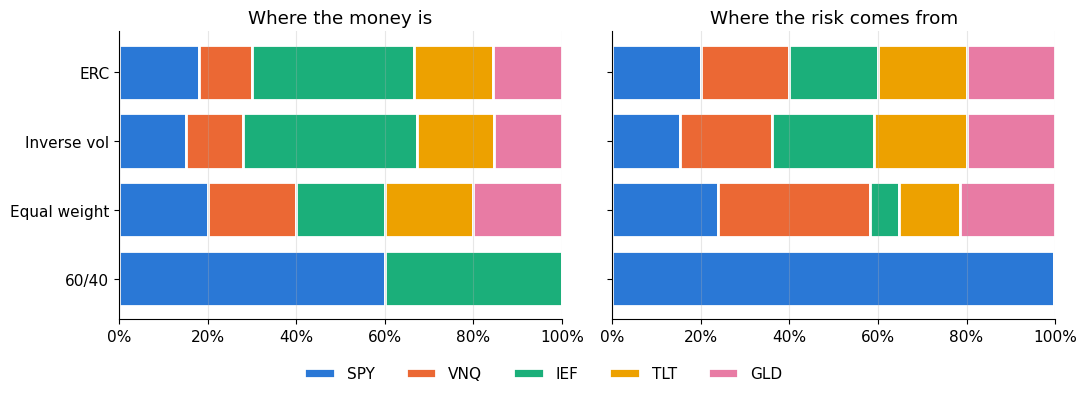

In [4]:
# Side-by-side: money weights vs. risk shares for each portfolio
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, data, title in [(axes[0], table, "Where the money is"), (axes[1], share, "Where the risk comes from")]:
    left = np.zeros(len(portfolios))
    for k, asset in enumerate(assets):
        ax.barh(list(portfolios), data.loc[asset], left=left, color=COLORS[k],
                edgecolor="white", linewidth=2, label=asset)
        left += data.loc[asset].values
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
    ax.grid(axis="y", visible=False)
fig.legend(*axes[0].get_legend_handles_labels(), frameon=False, ncol=5, loc="lower center")
plt.tight_layout(rect=(0, 0.08, 1, 1))     # leave room at the bottom for the shared legend
plt.show()

- **Equal weight is not equal risk.** VNQ (real estate) is the most volatile asset and alone provides about a third of the risk. IEF provides only 7%.
- **Inverse volatility gets close to balanced** (15–23% each) using only the five volatilities.
- **ERC is exactly balanced** at 20% each. Its weights differ from inverse-vol mainly where correlations matter: it adds a little to SPY and trims real estate, because VNQ and SPY tend to fall together.

To balance risk, both risk-parity versions hold almost 40% in the calmest asset (IEF).

### 4.4 Out-of-sample backtest

Weights are estimated each month from the past year of data and held for the next month. No look-ahead: each month uses only data available at the time.

In [5]:
month_ends = returns.groupby(returns.index.to_period("M")).tail(1).index
strategies = {"60/40": [], "Equal weight": [], "Inverse vol": [], "ERC": []}

for i, date in enumerate(month_ends[:-1]):
    past = returns.loc[:date].tail(252)
    if len(past) < 252:
        continue
    S = past.cov().values * 252
    nxt = returns.loc[date:month_ends[i + 1]].iloc[1:]           # next month, out of sample
    weights = {"60/40": w_6040, "Equal weight": np.full(len(assets), 1 / len(assets)),
               "Inverse vol": inverse_vol_weights(S), "ERC": erc_weights(S)}
    for name, w in weights.items():
        strategies[name].append(nxt @ w)

oos = pd.DataFrame({k: pd.concat(v) for k, v in strategies.items()})
rf = (prices["^IRX"].ffill() / 100 / 252).shift(1).reindex(oos.index)
excess = oos.sub(rf, axis=0)
value = (1 + oos).cumprod()
perf = pd.DataFrame({
    "CAGR": value.iloc[-1] ** (252 / len(oos)) - 1,
    "Volatility": oos.std() * np.sqrt(252),
    "Sharpe": np.sqrt(252) * excess.mean() / excess.std(),
    "Max drawdown": (value / value.cummax() - 1).min(),
})
fmt = {"CAGR": "{:.1%}", "Volatility": "{:.1%}", "Sharpe": "{:.2f}", "Max drawdown": "{:.1%}"}
perf.apply(lambda col: col.map(fmt[col.name].format))

,CAGR,Volatility,Sharpe,Max drawdown
60/40,9.5%,10.0%,0.81,-21.0%
Equal weight,7.2%,8.9%,0.65,-23.5%
Inverse vol,5.9%,7.5%,0.59,-22.3%
ERC,6.4%,7.6%,0.65,-22.3%


An honest result, and not a flattering one for risk parity:

- **60/40 won on every measure** in 2011–2026, a period dominated by a long bull market in US stocks. A portfolio that was ~100% stock risk was rewarded.
- **Risk parity delivered lower volatility** (about 7.5% vs 10%), as designed. But its max drawdown (−22%) was no better than 60/40's. The worst period for every portfolio here was 2022, when stocks *and* bonds fell together, and risk parity's large bond holdings offered no protection.
- **ERC and inverse vol performed almost identically.** The simple version captures most of the idea.

Risk parity is a bet on *balance*, not on any one asset class. It looks best in periods when stocks struggle and the other assets diversify, such as 2000–2010, which is not in our sample.

## 5. Takeaways and where it breaks

- **Money weights are not risk weights.** Always look at risk contributions; a "diversified" portfolio can be one big bet.
- **Risk parity needs no return forecasts**, only the covariance matrix, which is the input we can estimate well (P1, P2).
- **Low volatility, not necessarily high return.** Risk-parity portfolios hold a lot of bonds. Funds that run them usually use leverage to reach a target volatility. That adds borrowing costs, and amplifies losses when stocks and bonds fall together, as in 2022.
- **It relies on correlations staying put.** ERC weights bonds heavily because they *used to* hedge stocks. When that relationship broke (notebook 3), risk parity had one of its worst years.
- **Extension, Hierarchical Risk Parity (HRP):** first cluster similar assets (e.g. the two Treasury funds) with a tree, then split risk between clusters before splitting within them. It avoids inverting $\Sigma$ altogether and is a natural next step.

**What you could build:** a risk-budgeting tool where the team sets a target share of risk per asset class (e.g. 40% equities, 40% rates, 20% real assets) and gets the weights that deliver it.